# Stim — prise en main

## 1. Premier circuit Stim

## 2. Mesures brutes

## 3. Détecteurs

## 4. Bruits

## 5. Circuit de correction d'erreur

## 6. Detector Error Model

## 6. Detector Error Model

## 7. Traduction DEM vers H, A, p

In [3]:
import sys
print(sys.executable)

/home/ajyad/Documents/VSCode/.venv/bin/python


In [4]:
import stim
print(stim.__version__)

1.16.0


## 1. Premier circuit Stim

1.1 Création d'un circuit Bell: prépare une paire Bell et la mesure dans la base Z
    -un circuit est une instance de stim.Circuit
    -on ajoute des opération avec circuit.append(nom_porte,cibles), cibles est une liste d'entiers ou chaque entiers représente le i-e qubit

In [5]:
circuit=stim.Circuit()
#Création de la paire Bell en utilisant la porte HADAMARD et la porte CNOT
circuit.append("H",[0])
circuit.append("CNOT",[0,1])
#Mesure des qubits
circuit.append("M",[0,1])

Afficher la représentation du circuit. RQ: ce n'est pas l'éxecution de la simulation

In [6]:
circuit

stim.Circuit('''
    H 0
    CX 0 1
    M 0 1
''')

Diagramme textuel annoté

In [7]:
circuit.diagram()

q0: -H-@-M:rec[0]-
       |
q1: ---X-M:rec[1]-

Diagramme SVG temporel

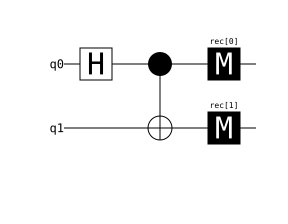

In [8]:
circuit.diagram("timeline-svg")

## 2. Mesures brutes

Echantillonnage des mesures:
    -Pour échantilloner des mesure, on utilise un sampler

In [13]:
sampler=circuit.compile_sampler()
print(sampler.sample(shots=10))

[[False False]
 [False False]
 [False False]
 [False False]
 [False False]
 [False False]
 [False False]
 [False False]
 [ True  True]
 [False False]]


## 3. Détecteurs

Ajouts de détecteurs:
    -s'ajoute au circuit comme un opérateur, les cibles sont maintenant des mesures ( stim.target_rec(i) )

In [14]:
circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-2)])
circuit

stim.Circuit('''
    H 0
    CX 0 1
    M 0 1
    DETECTOR rec[-1] rec[-2]
''')

Echantillonage des detecteur :
    -on utilise circuit.compile_detector_sampler()
    -Le résultat est une matrice taille N*P ou N: nombre de mesure, P:nombre de detecteurs dans le circuit

In [15]:
sampler=circuit.compile_detector_sampler()
print(sampler.sample(shots=5))

[[False]
 [False]
 [False]
 [False]
 [False]]


## 3. Bruits

Mise en place d'un circuit bruité, erreur X avec une proba 0.2 sur les 2 qubits

In [20]:
circuit=stim.Circuit('''
    H 0
    TICK
    
    CX 0 1 
    X_ERROR(0.2) 0 1
    TICK
    
    M 0 1
    DETECTOR rec[-1] rec[-2]
    ''')

In [21]:
sampler=circuit.compile_detector_sampler()
print(sampler.sample(shots=5))

[[False]
 [False]
 [ True]
 [ True]
 [False]]


Diagramme en tranche temporelle

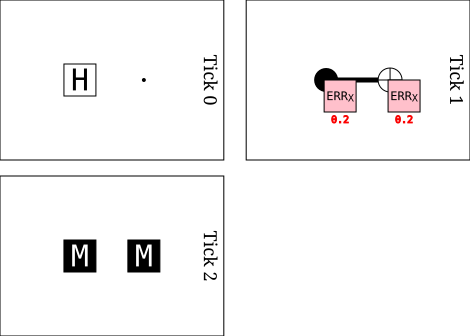

In [22]:
circuit.diagram("timeslice-svg")

Estimation Monte Carlo de la probabilité de détection p: rq: p!=0.2 car détection si qubit 1 flip et qubit 2 ne flip pas ou qubit 1 ne flip pas et qubit 2 flip. Si les 2 flip alors pas de détection donc p=0.2*0.8+0.8*0.2=0.32 

In [23]:
import numpy as np
print(np.sum(sampler.sample(shots=10**6))/10**6)

0.320181


## 5. Circuit de correction d'erreur

1.Circuit de code de répétition: simple à visualiser:
    -comprendre le fonctionnement d'un circuit de correction d'erreur et comment en implémenter ( la distance considéré pour le circuit de code de répétition ne prend en compte que les erreurs de flip )

stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
    TICK
    DEPOLARIZE1(0.04) 0 2 4 6 8 10 12 14 16
    CX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 1 4 3 6 5 8 7 10 9 12 11 14 13 16 15
    TICK
    X_ERROR(0.01) 1 3 5 7 9 11 13 15
    MR 1 3 5 7 9 11 13 15
    DETECTOR(1, 0) rec[-8]
    DETECTOR(3, 0) rec[-7]
    DETECTOR(5, 0) rec[-6]
    DETECTOR(7, 0) rec[-5]
    DETECTOR(9, 0) rec[-4]
    DETECTOR(11, 0) rec[-3]
    DETECTOR(13, 0) rec[-2]
    DETECTOR(15, 0) rec[-1]
    REPEAT 24 {
        TICK
        DEPOLARIZE1(0.04) 0 2 4 6 8 10 12 14 16
        CX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
        TICK
        CX 2 1 4 3 6 5 8 7 10 9 12 11 14 13 16 15
        TICK
        X_ERROR(0.01) 1 3 5 7 9 11 13 15
        MR 1 3 5 7 9 11 13 15
        SHIFT_COORDS(0, 1)
        DETECTOR(1, 0) rec[-8] rec[-16]
        DETECTOR(3, 0) rec[-7] rec[-15]
        DETECTOR(5, 0) rec[-6] rec[-14]
        DETECTOR(7, 0) rec[-5] rec[-13]
        DETECTOR(9, 0) rec[-4] r

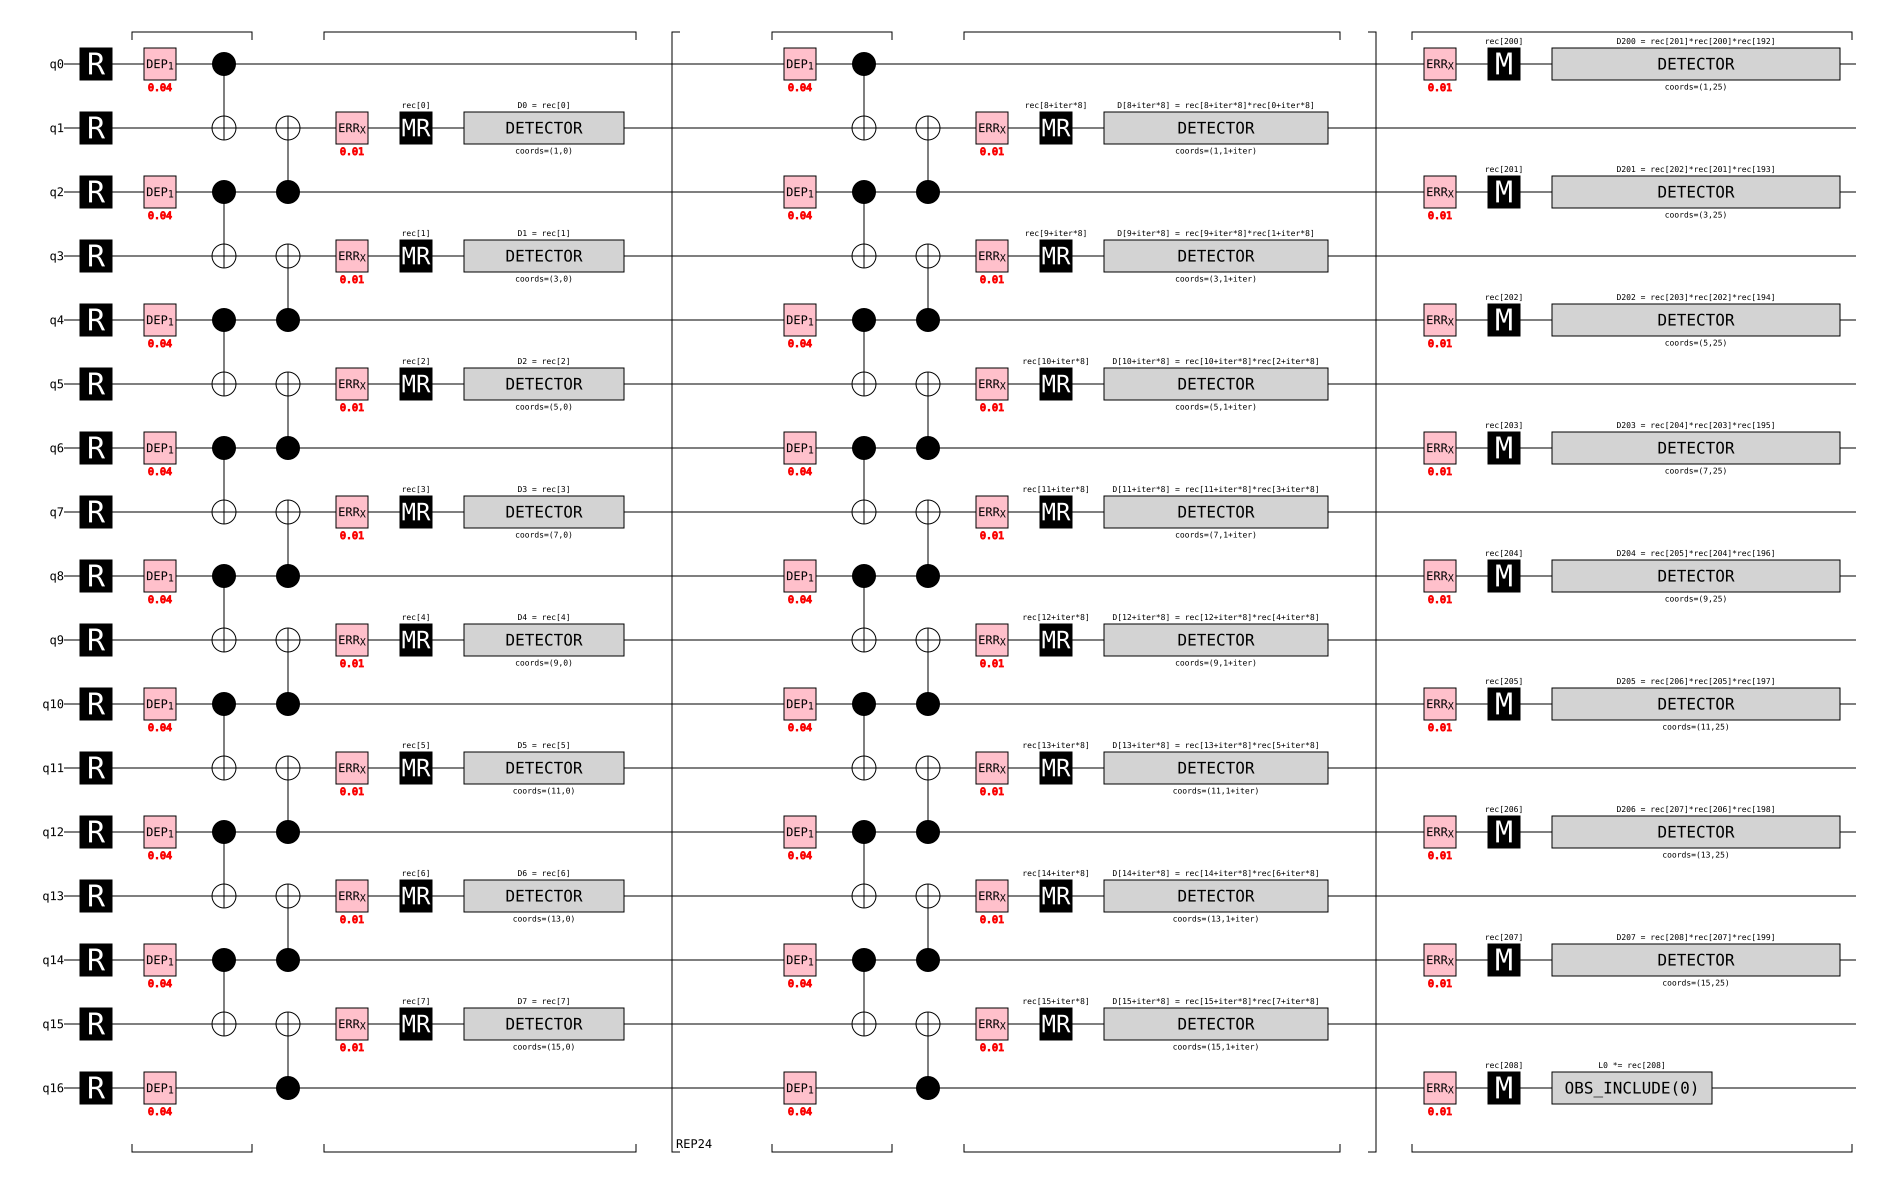

In [25]:
circuit=stim.Circuit.generated(
    "repetition_code:memory",
    rounds=25,
    distance=9,
    before_round_data_depolarization=0.04,
    before_measure_flip_probability=0.01)
print(repr(circuit))
circuit.diagram("timeline-svg")

Afficher une trajectoire de mesures brutes, les 1 correspondent à une mesure 1, les _ une mesure 0

In [32]:
sampler=circuit.compile_sampler()
one_sample=sampler.sample(shots=1)[0]
for k in range(0,len(one_sample),8):
    timeslice=one_sample[k:k+8]
    print("".join("1" if e else "_" for e in timeslice))

________
________
________
________
_1______
________
________
________
_11_____
_11_____
_11_____
111_____
111_____
_11_____
111_____
111__11_
111__11_
111__11_
111__11_
11_1_11_
11_1_11_
11_1_11_
11_1_11_
111__11_
111_111_
1_1___1_
_


Afficher une trajectoire d’événements de détection, les ! mesure une detection

In [34]:
sampler=circuit.compile_detector_sampler()
one_sampler=sampler.sample(shots=1)[0]
for k in range(0,len(one_sampler),8):
    timeslice=one_sampler[k:k+8]
    print("".join("!" if e else "_" for e in timeslice))

________
_!!!____
___!____
________
________
______!!
________
__!!____
________
___!!___
________
________
!_!!____
________
________
________
________
________
_______!
_______!
________
________
__!!_!__
_____!__
________
________


## 6. Detector Error Model

Le detector error model décrit les mécanismes d'erreurs possible, leur probabilité, les detecteurs qu'il déclenche, l'erreur logique provoqué

In [35]:
dem=circuit.detector_error_model()
print(repr(dem))

stim.DetectorErrorModel('''
    error(0.0266667) D0
    error(0.0266667) D0 D1
    error(0.01) D0 D8
    error(0.0266667) D1 D2
    error(0.01) D1 D9
    error(0.0266667) D2 D3
    error(0.01) D2 D10
    error(0.0266667) D3 D4
    error(0.01) D3 D11
    error(0.0266667) D4 D5
    error(0.01) D4 D12
    error(0.0266667) D5 D6
    error(0.01) D5 D13
    error(0.0266667) D6 D7
    error(0.01) D6 D14
    error(0.01) D7 D15
    error(0.0266667) D7 L0
    detector(1, 0) D0
    detector(3, 0) D1
    detector(5, 0) D2
    detector(7, 0) D3
    detector(9, 0) D4
    detector(11, 0) D5
    detector(13, 0) D6
    detector(15, 0) D7
    repeat 23 {
        error(0.0266667) D8
        error(0.0266667) D8 D9
        error(0.01) D8 D16
        error(0.0266667) D9 D10
        error(0.01) D9 D17
        error(0.0266667) D10 D11
        error(0.01) D10 D18
        error(0.0266667) D11 D12
        error(0.01) D11 D19
        error(0.0266667) D12 D13
        error(0.01) D12 D20
        error(0.0266667) D1

Stim peut produire un graphe de matching; graphe de matching != tanner graphe, 
le graph de matching est ce qu'utilise MWPM, les arretes sont des erreurs, les noeuds des detecteurs, si une erreur est conecté 1 seul detecteurs
alors on cree une arrete avec la frontière. Si erreur connecté à plus de 3 detecteurs, impossible de la représenter

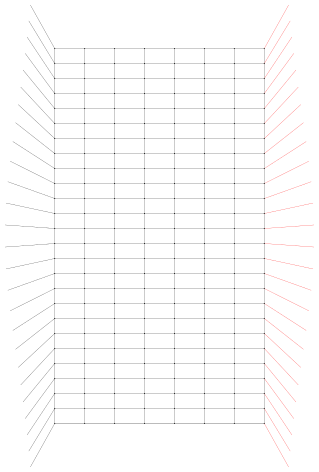

In [36]:
dem.diagram("matchgraph-svg")